In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install timm facenet-pytorch opencv-python-headless albumentations grad-cam -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 69.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 88.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 MB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 83.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 90.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 850.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 96.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 92.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 63.6 MB/s eta 0:

In [ ]:
!pip uninstall facenet-pytorch -y
!pip install timm opencv-python-headless albumentations grad-cam -q


Found existing installation: facenet-pytorch 2.6.0
Uninstalling facenet-pytorch-2.6.0:
  Successfully uninstalled facenet-pytorch-2.6.0


In [ ]:
import torch
import timm
import cv2
import albumentations
print("torch:", torch.__version__)
print("timm:", timm.__version__)
print("cv2:", cv2.__version__)
print("CUDA available:", torch.cuda.is_available())

torch: 2.2.2+cu121
timm: 1.0.25
cv2: 4.11.0
CUDA available: True


In [ ]:
import os
os.environ['KAGGLE_USERNAME'] = 'sameera6301'
os.environ['KAGGLE_KEY'] = 'paste_your_new_token_here'

!kaggle datasets download -d xhlulu/140k-real-and-fake-faces -p /content/drive/MyDrive/deepfake/

Dataset URL: https://www.kaggle.com/datasets/xhlulu/140k-real-and-fake-faces
License(s): other
100% 3.75G/3.75G [00:36<00:00, 111MB/s] 



In [ ]:
!unzip /content/drive/MyDrive/deepfake/140k-real-and-fake-faces.zip -d /content/drive/MyDrive/deepfake/data/
print("Unzip complete!")

Streaming output truncated to the last 5000 lines.
  inflating: /content/drive/MyDrive/deepfake/data/real_vs_fake/real-vs-fake/valid/real/34836.jpg  
  inflating: /content/drive/MyDrive/deepfake/data/real_vs_fake/real-vs-fake/valid/real/34839.jpg  
  inflating: /content/drive/MyDrive/deepfake/data/real_vs_fake/real-vs-fake/valid/real/34847.jpg  
  inflating: /content/drive/MyDrive/deepfake/data/real_vs_fake/real-vs-fake/valid/real/34848.jpg  
  inflating: /content/drive/MyDrive/deepfake/data/real_vs_fake/real-vs-fake/valid/real/34852.jpg  
  inflating: /content/drive/MyDrive/deepfake/data/real_vs_fake/real-vs-fake/valid/real/34861.jpg  
  inflating: /content/drive/MyDrive/deepfake/data/real_vs_fake/real-vs-fake/valid/real/34864.jpg  
  inflating: /content/drive/MyDrive/deepfake/data/real_vs_fake/real-vs-fake/valid/real/34868.jpg  
  inflating: /content/drive/MyDrive/deepfake/data/real_vs_fake/real-vs-fake/valid/real/34877.jpg  
  inflating: /content/drive/MyDrive/deepfake/data/real_vs_

In [ ]:
import os

# Find actual structure
base = '/content/drive/MyDrive/deepfake/data/'
for root, dirs, files in os.walk(base):
    level = root.replace(base, '').count(os.sep)
    if level < 4:  # only show first 4 levels
        indent = ' ' * 2 * level
        print(f'{indent}{os.path.basename(root)}/')

/
real_vs_fake/
  real-vs-fake/
    test/
      fake/
      real/
    train/
      fake/
      real/
    valid/
      fake/
      real/


In [ ]:
import os

data_root = '/content/drive/MyDrive/deepfake/data/real_vs_fake/real-vs-fake/'

for split in ['train', 'valid', 'test']:
    for label in ['real', 'fake']:
        path = os.path.join(data_root, split, label)
        count = len(os.listdir(path))
        print(f"{split}/{label}: {count} images")

train/real: 50000 images
train/fake: 50000 images
valid/real: 10000 images
valid/fake: 10000 images
test/real: 10000 images
test/fake: 10000 images


In [ ]:
!pip install timm opencv-python-headless albumentations grad-cam -q

In [ ]:
import torch
import torch.nn as nn
import timm
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

# Correct data root
data_root = '/content/drive/MyDrive/deepfake/data/real_vs_fake/real-vs-fake/'

# Transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Load datasets
train_dataset = datasets.ImageFolder(data_root + 'train/', transform=train_transform)
val_dataset   = datasets.ImageFolder(data_root + 'valid/', transform=val_transform)
test_dataset  = datasets.ImageFolder(data_root + 'test/',  transform=val_transform)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")
print(f"Classes: {train_dataset.classes}")

Device: cuda
Train: 100000 | Val: 20000 | Test: 20000
Classes: ['fake', 'real']


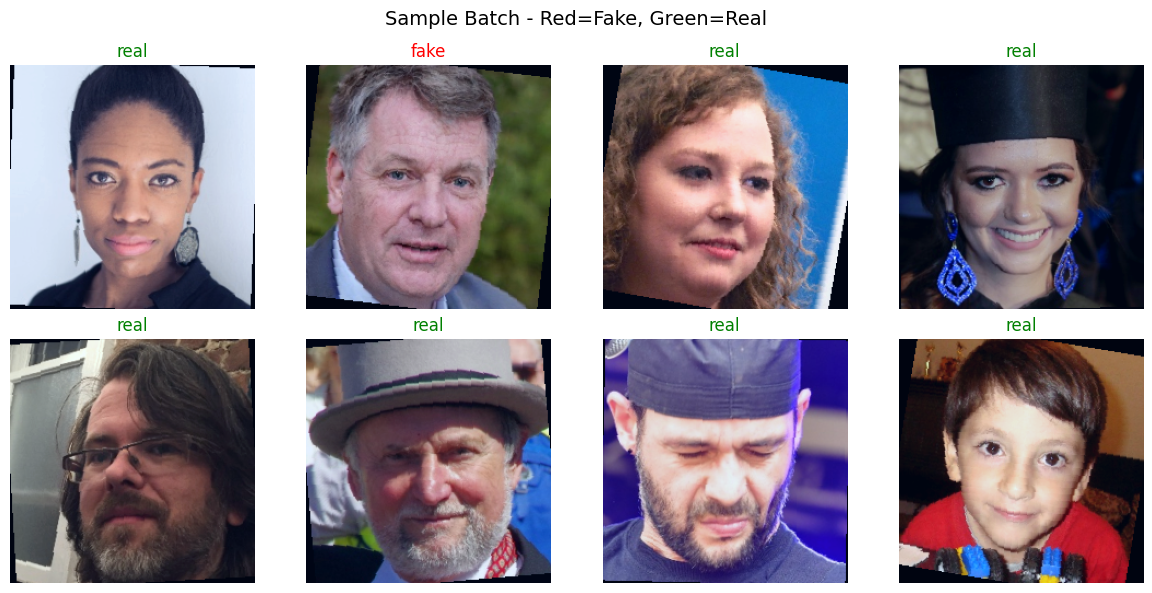

Sample batch saved!


In [ ]:
# Visualize sample batch
import matplotlib.pyplot as plt
import os

os.makedirs('/content/drive/MyDrive/deepfake/results/', exist_ok=True)

images, labels = next(iter(train_loader))
class_names = train_dataset.classes

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    img = images[i].permute(1,2,0).numpy()
    img = (img - img.min()) / (img.max() - img.min())
    ax.imshow(img)
    ax.set_title(class_names[labels[i]],
                 color='red' if class_names[labels[i]]=='fake' else 'green',
                 fontsize=12)
    ax.axis('off')

plt.suptitle('Sample Batch - Red=Fake, Green=Real', fontsize=14)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/deepfake/results/sample_batch.png')
plt.show()
print("Sample batch saved!")

In [ ]:
import timm
import torch
import torch.nn as nn

# Squeeze-and-Excitation Attention Block
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.se = nn.Sequential(
            nn.Linear(channels, channels // reduction),
            nn.ReLU(),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.se(x)
        return x * scale

# Main Deepfake Detector Model
class DeepfakeDetector(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model('efficientnet_b4',
                                           pretrained=True,
                                           num_classes=0)
        num_features = self.backbone.num_features

        self.classifier = nn.Sequential(
            SEBlock(num_features),
            nn.Dropout(0.4),
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.3),
            nn.Linear(512, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        features = self.backbone(x)
        output = self.classifier(features)
        return output

# Initialize model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = DeepfakeDetector().to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Device: {device}")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print("Model built successfully!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

Device: cuda
Total parameters: 18,871,481
Trainable parameters: 18,871,481
Model built successfully!


In [ ]:
from torch.utils.data import DataLoader, Subset
import random

random.seed(42)
train_indices = random.sample(range(len(train_dataset)), 10000)
val_indices   = random.sample(range(len(val_dataset)),   2000)
test_indices  = random.sample(range(len(test_dataset)),  2000)

small_train = Subset(train_dataset, train_indices)
small_val   = Subset(val_dataset,   val_indices)
small_test  = Subset(test_dataset,  test_indices)

train_loader = DataLoader(small_train, batch_size=64, shuffle=True,  num_workers=2)
val_loader   = DataLoader(small_val,   batch_size=64, shuffle=False, num_workers=2)
test_loader  = DataLoader(small_test,  batch_size=64, shuffle=False, num_workers=2)

print(f"Train: {len(small_train)} | Val: {len(small_val)} | Test: {len(small_test)}")

Train: 10000 | Val: 2000 | Test: 2000


In [ ]:
# ── Imports ──
import torch, torch.nn as nn, timm, os, random, time
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, Subset
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from google.colab import drive
drive.mount('/content/drive')

# ── Device ──
torch.cuda.empty_cache()
device = torch.device('cuda')
print("Device:", device)

# ── Data ──
data_root = '/content/drive/MyDrive/deepfake/data/real_vs_fake/real-vs-fake/'
transform_train = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
transform_val = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
train_dataset = datasets.ImageFolder(data_root+'train/', transform=transform_train)
val_dataset   = datasets.ImageFolder(data_root+'valid/', transform=transform_val)
test_dataset  = datasets.ImageFolder(data_root+'test/',  transform=transform_val)

random.seed(42)
small_train = Subset(train_dataset, random.sample(range(len(train_dataset)), 10000))
small_val   = Subset(val_dataset,   random.sample(range(len(val_dataset)),   2000))
small_test  = Subset(test_dataset,  random.sample(range(len(test_dataset)),  2000))

train_loader = DataLoader(small_train, batch_size=16, shuffle=True,  num_workers=2)
val_loader   = DataLoader(small_val,   batch_size=16, shuffle=False, num_workers=2)
test_loader  = DataLoader(small_test,  batch_size=16, shuffle=False, num_workers=2)
print(f"Train:{len(small_train)} Val:{len(small_val)} Test:{len(small_test)}")

# ── Model ──
class DeepfakeDetector(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model('efficientnet_b0',
                                           pretrained=True,
                                           num_classes=0)
        nf = self.backbone.num_features
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(nf, 256),
            nn.ReLU(),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.classifier(self.backbone(x))

model = DeepfakeDetector().to(device)
print("Model ready!")

# ── Train ──
criterion = nn.BCELoss()
optimizer = AdamW(model.parameters(), lr=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=15)
history   = {'train_acc':[], 'val_acc':[]}
best_val  = 0.0

for epoch in range(15):
    start = time.time()
    model.train()
    correct, total = 0, 0
    for imgs, labs in train_loader:
        imgs, labs = imgs.to(device), labs.float().to(device)
        optimizer.zero_grad()
        out  = model(imgs).squeeze()
        loss = criterion(out, labs)
        loss.backward()
        optimizer.step()
        correct += ((out>0.5)==labs).sum().item()
        total   += labs.size(0)
    train_acc = correct/total

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labs in val_loader:
            imgs, labs = imgs.to(device), labs.float().to(device)
            out = model(imgs).squeeze()
            correct += ((out>0.5)==labs).sum().item()
            total   += labs.size(0)
    val_acc = correct/total
    scheduler.step()

    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    print(f"Epoch {epoch+1:02d}/15 | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Time: {time.time()-start:.1f}s")

    if val_acc > best_val:
        best_val = val_acc
        torch.save(model.state_dict(), '/content/drive/MyDrive/deepfake/best_model.pth')
        print(f"  ✅ Saved! Val Acc: {val_acc:.4f}")

print("Training complete!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
Train:10000 Val:2000 Test:2000


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Model ready!
Epoch 01/15 | Train Acc: 0.8937 | Val Acc: 0.9705 | Time: 234.2s
  ✅ Saved! Val Acc: 0.9705
Epoch 02/15 | Train Acc: 0.9731 | Val Acc: 0.9870 | Time: 222.8s
  ✅ Saved! Val Acc: 0.9870
Epoch 03/15 | Train Acc: 0.9879 | Val Acc: 0.9845 | Time: 204.9s
Epoch 04/15 | Train Acc: 0.9932 | Val Acc: 0.9770 | Time: 227.0s
Epoch 05/15 | Train Acc: 0.9914 | Val Acc: 0.9895 | Time: 120.5s
  ✅ Saved! Val Acc: 0.9895
Epoch 06/15 | Train Acc: 0.9944 | Val Acc: 0.9845 | Time: 118.4s
Epoch 07/15 | Train Acc: 0.9974 | Val Acc: 0.9945 | Time: 116.7s
  ✅ Saved! Val Acc: 0.9945
Epoch 08/15 | Train Acc: 0.9980 | Val Acc: 0.9875 | Time: 117.6s
Epoch 09/15 | Train Acc: 0.9987 | Val Acc: 0.9930 | Time: 115.7s
Epoch 10/15 | Train Acc: 0.9999 | Val Acc: 0.9945 | Time: 117.1s
Epoch 11/15 | Train Acc: 0.9994 | Val Acc: 0.9930 | Time: 119.1s
Epoch 12/15 | Train Acc: 0.9999 | Val Acc: 0.9960 | Time: 116.2s
  ✅ Saved! Val Acc: 0.9960
Epoch 13/15 | Train Acc: 0.9998 | Val Acc: 0.9965 | Time: 111.9s
  ✅ Sav

              precision    recall  f1-score   support

        fake       0.99      1.00      1.00      1025
        real       1.00      0.99      1.00       975

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

AUC-ROC: 0.9999059412132583


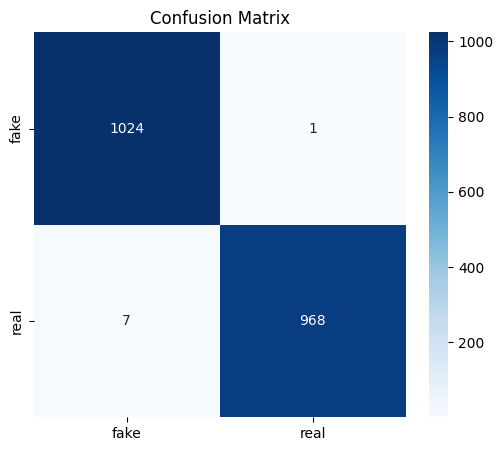

Confusion matrix saved!


In [2]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

model.eval()
all_preds, all_probs, all_labels = [], [], []

with torch.no_grad():
    for imgs, labs in test_loader:
        out = model(imgs.to(device)).squeeze().cpu()
        all_probs.extend(out.numpy())
        all_preds.extend((out>0.5).int().numpy())
        all_labels.extend(labs.numpy())

print(classification_report(all_labels, all_preds, target_names=['fake','real']))
print("AUC-ROC:", roc_auc_score(all_labels, all_probs))

plt.figure(figsize=(6,5))
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['fake','real'],
            yticklabels=['fake','real'], cmap='Blues')
plt.title('Confusion Matrix')
plt.savefig('/content/drive/MyDrive/deepfake/results/confusion_matrix.png')
plt.show()
print("Confusion matrix saved!")

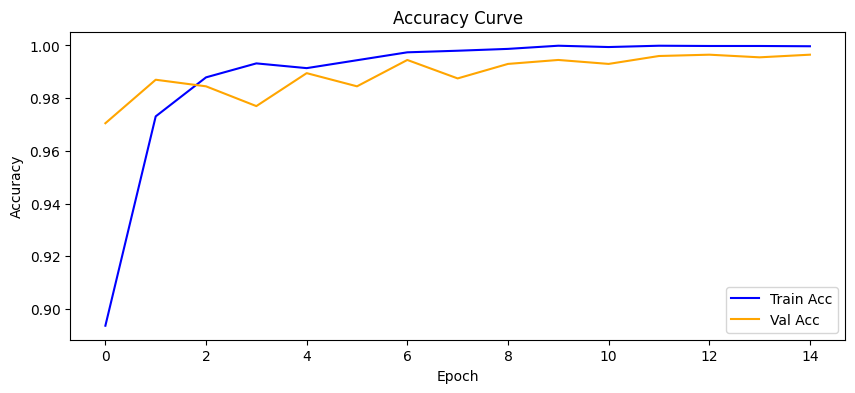

Training curves saved!


In [3]:
plt.figure(figsize=(10,4))
plt.plot(history['train_acc'], label='Train Acc', color='blue')
plt.plot(history['val_acc'],   label='Val Acc',   color='orange')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig('/content/drive/MyDrive/deepfake/results/training_curves.png')
plt.show()
print("Training curves saved!")

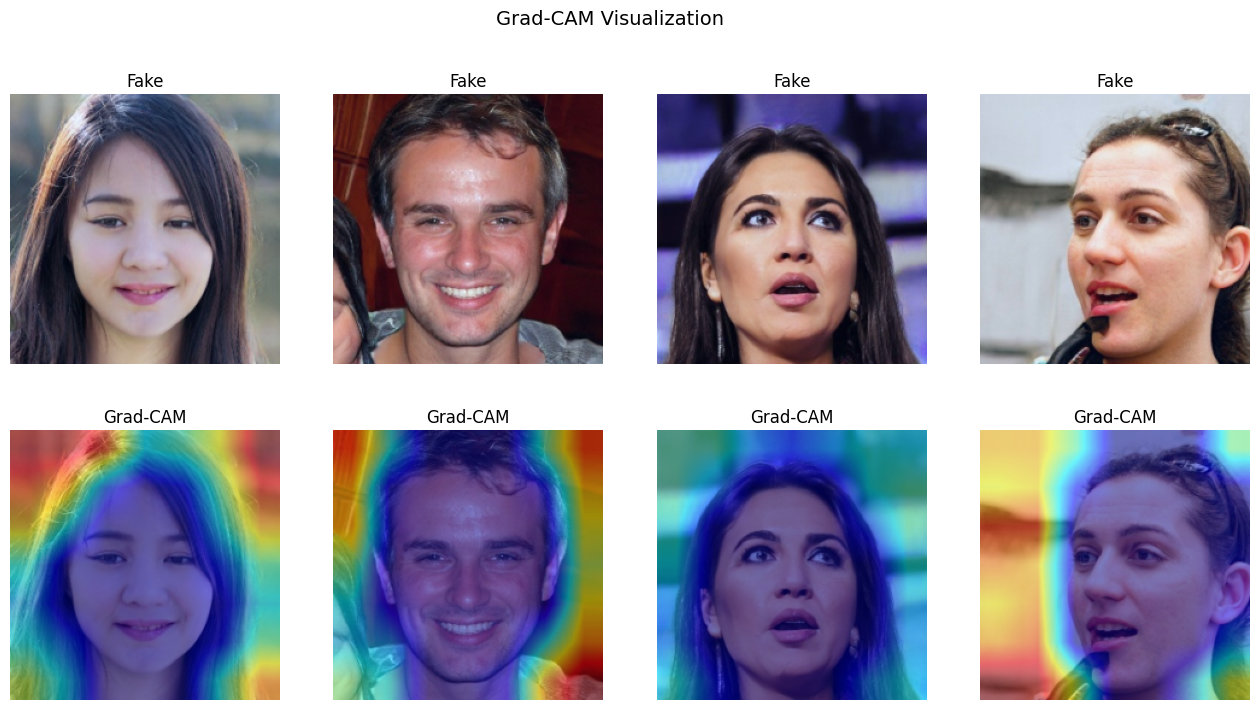

Grad-CAM saved!


In [5]:
!pip install grad-cam -q
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import BinaryClassifierOutputTarget

target_layers = [model.backbone.conv_head]
cam = GradCAM(model=model, target_layers=target_layers)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i in range(4):
    img_tensor, label = test_dataset[i]
    input_tensor = img_tensor.unsqueeze(0).to(device)
    grayscale_cam = cam(input_tensor=input_tensor,
                        targets=[BinaryClassifierOutputTarget(1)])
    rgb_img = img_tensor.permute(1,2,0).numpy()
    rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min())
    visualization = show_cam_on_image(rgb_img.astype(np.float32),
                                       grayscale_cam[0], use_rgb=True)
    axes[0][i].imshow(rgb_img)
    axes[0][i].set_title(f"{'Fake' if label==0 else 'Real'}")
    axes[0][i].axis('off')
    axes[1][i].imshow(visualization)
    axes[1][i].set_title("Grad-CAM")
    axes[1][i].axis('off')

plt.suptitle('Grad-CAM Visualization', fontsize=14)
plt.savefig('/content/drive/MyDrive/deepfake/results/gradcam.png')
plt.show()
print("Grad-CAM saved!")



In [6]:
!pip install gradio -q


In [7]:
import gradio as gr
import torch
from torchvision import transforms
from PIL import Image
import numpy as np

# Load model
model.eval()

# Transform for input image
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

def predict(image):
    # Preprocess
    img = transform(image).unsqueeze(0).to(device)

    # Predict
    with torch.no_grad():
        output = model(img).squeeze().item()

    # output close to 1 = real, close to 0 = fake
    real_prob = output
    fake_prob = 1 - output

    return {
        "REAL": round(real_prob, 4),
        "FAKE": round(fake_prob, 4)
    }

# Launch Gradio app
demo = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil", label="Upload Face Image"),
    outputs=gr.Label(num_top_classes=2, label="Prediction"),
    title="🔍 Deepfake Detection System",
    description="Upload a face image to detect if it is REAL or FAKE using EfficientNet-B0 trained on 140k faces.",
    examples=[],
    theme=gr.themes.Soft()
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://03e1105b12b671a4e8.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
